# In this notebook we explore the respone terms of the single link

In [13]:
import h5py
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.usetex'] = True

from lisaconstants import c
from lisaconstants.indexing import LINKS
from pytdi.michelson import X2_ETA, Y2_ETA, Z2_ETA

from segwo.response import compute_strain2link
from segwo_utils import _link_response_boosted

from segwo_utils import InterpolatedOrbits, compute_covariance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings


In [14]:
with h5py.File("processed_trajectories.h5", "r") as ds:
        t_orb_dataset   = ds["t_interp"][()]
        x_orb_dataset   = ds["spacecraft_positions"][()]
        v_orb_dataset   = ds["spacecraft_velocities"][()]
        ltts_dataset    = ds['owlt_12_23_31_13_32_21'][()]

t_orb        = t_orb_dataset
x_orb        = np.median(x_orb_dataset, axis=0)
v_orb        = np.median(v_orb_dataset, axis=0)
ltts_median  = np.median(ltts_dataset,  axis=0)

In [15]:
t_orb[1]-t_orb[0]

np.float64(86400.0)

In [16]:
orbits = InterpolatedOrbits(t_orb, x_orb,
                                spacecraft_velocities=v_orb,
                                ltts=ltts_median,
                                interp_order=3)

In [17]:
array_ltts = np.arange(0,365,1) * 86400.0
# array_ltts = np.arange(0, 3600, 0.5)
print("Number of points in LISA", int(array_ltts[-1]*0.25))

Number of points in LISA 7862400


# Light Travel Times

Text(0, 0.5, ' dLTT/dt')

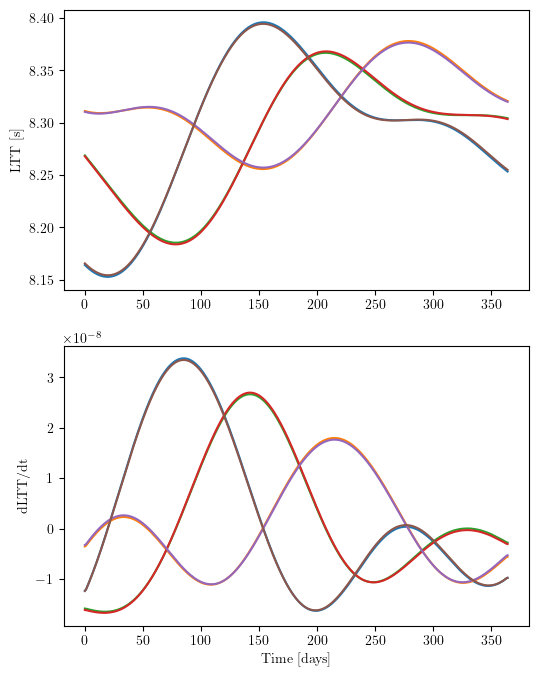

In [18]:
ltts      = orbits.compute_ltt(t=array_ltts)
positions = orbits.compute_position(t=array_ltts)

_, axes = plt.subplots(2, 1,figsize=(6,8))
for index, link in enumerate(LINKS):
    axes[0].plot(array_ltts/86400, ltts[:, index], label=link)
    axes[1].plot(array_ltts/86400, np.gradient(ltts[:, index], array_ltts), label=link)

plt.xlabel('Time [days]')
axes[0].set_ylabel('LTT [s]')
axes[1].set_ylabel(' dLTT/dt')


In [19]:
nside = 2
npix  = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
# betas, lambs = np.pi / 2 - thetas, phis
betas, lambs = np.pi / 2 - np.array([np.pi/3]), np.array([np.pi/3])
f = np.logspace(-4, 0., 500)

strain2link = compute_strain2link(f, betas, lambs, ltts, positions, method="baghi+23")
strain2link_boosted = _link_response_boosted(f, betas, lambs, ltts, positions, velocities=orbits.compute_velocity(t=array_ltts))
strain2link_boosted.shape

(365, 500, 1, 6, 2)

In [20]:
import matplotlib.colors as mcolors


def symmetrical_colormap(cmap_settings, new_name = None ):
    ''' This function take a colormap and create a new one, as the concatenation of itself by a symmetrical fold.
    '''
    # get the colormap
    cmap = plt.cm.get_cmap(*cmap_settings)
    if not new_name:
        new_name = "sym_"+cmap_settings[0]  # ex: 'sym_Blues'
    
    # this defined the roughness of the colormap, 128 fine
    n= 128 
    
    # get the list of color from colormap
    colors_r = cmap(np.linspace(0, 1, n))    # take the standard colormap # 'right-part'
    colors_l = colors_r[::-1]                # take the first list of color and flip the order # "left-part"

    # combine them and build a new colormap
    colors = np.vstack((colors_l, colors_r))
    mymap = mcolors.LinearSegmentedColormap.from_list(new_name, colors)

    return mymap

cmap_settings = ('Blues', None)  # provide int instead of None to "discretize/bin" the colormap
mymap = symmetrical_colormap(cmap_settings= cmap_settings, new_name =None )


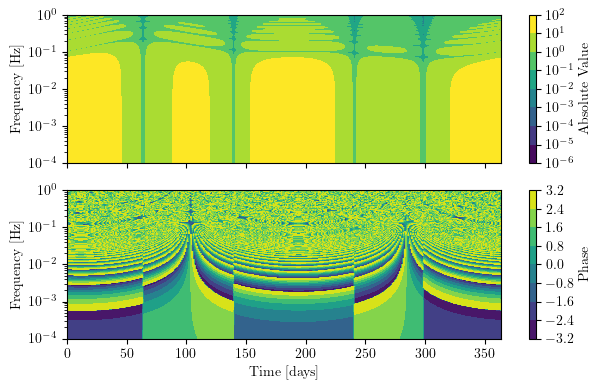

In [21]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

response = strain2link[:, :, sky_index, link, pol] / f
amp_map = (np.abs(response).T)
phase_map = (np.angle(response).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

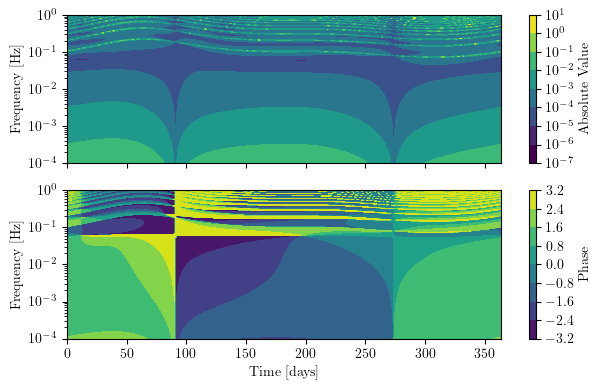

In [24]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index

response = (strain2link[:, :, sky_index, link, pol] - strain2link_boosted[:, :, sky_index, link, pol]) / strain2link_boosted[:, :, sky_index, link, pol]
amp_map = (np.abs(response).T)
phase_map = (np.angle(response).T)

fig, axes = plt.subplots(2, 1, figsize=(3.15*2, 4), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("response_evolution.png", dpi=300)

In [10]:
link = 0  # Choose A, E, or T
pol = 0  # Choose polarization
sky_index = 0  # Choose a specific sky location (pixel index)
time_index = 0  # Choose a specific time index


[]

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

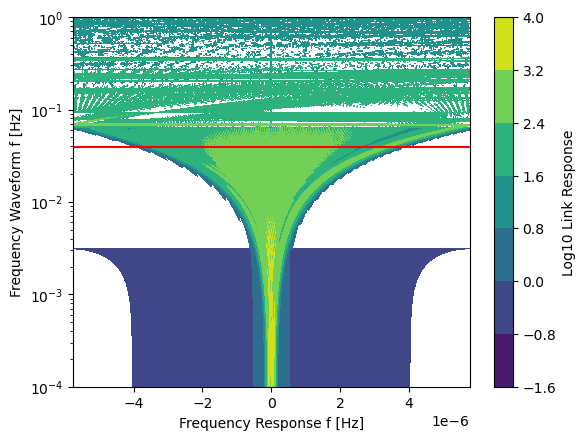

In [11]:
fft_g = np.fft.fft(strain2link[:,:,sky_index,link,pol],axis=0)

f_prime = np.fft.fftfreq(array_ltts.shape[0], d=array_ltts[1]-array_ltts[0])
plt.figure()
plt.contourf(f_prime, f, np.log10(np.abs(fft_g/f).T))
plt.colorbar(label='Log10 Link Response')
plt.axhline(1/(np.pi*8.2), color='r')
plt.xlabel('Frequency Response f [Hz]')
plt.ylabel('Frequency Waveform f [Hz]')
plt.semilogy()

In [14]:
# Covariance

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


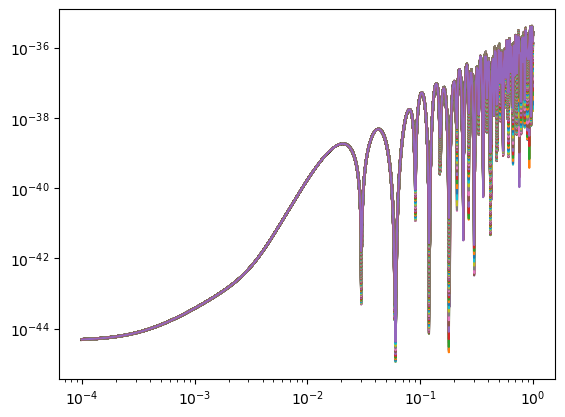

In [34]:
noise_cov_aet = compute_covariance(f, ltts)

plt.loglog(f, noise_cov_aet[:,:,0,0].T, label='A')
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

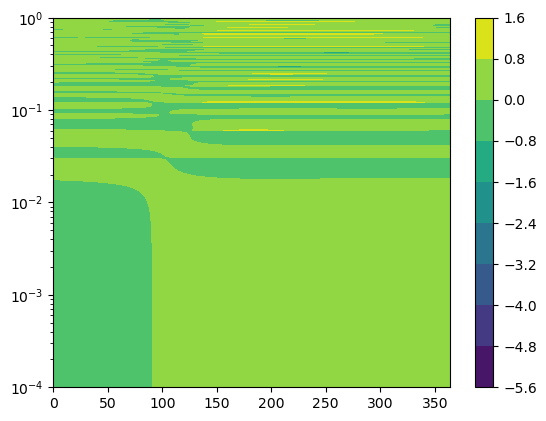

In [31]:
plt.contourf(array_ltts / 86400, f,np.log10(noise_cov_aet[:,:,0,0]/noise_cov_aet[0,:,0,0]).T)
plt.colorbar()
plt.semilogy()
plt.show()